# Phase 3: Data Preprocessing & Feature Engineering
## Credit Card Fraud Detection System (Deep Learning Portfolio)

### Objectives:
1. **Drop Irrelevant Identifiers**: Remove `transaction_id` to avoid data leakage.
2. **Cyclical Time Encoding**: Transform `transaction_hour` into `hour_sin` and `hour_cos` to preserve numerical adjacency (e.g., 23:00 and 00:00 are close).
3. **One-Hot Encoding**: Represent `merchant_category` as binary columns.
4. **Stratified Splitting**: Partition data into Train/Val/Test (70/15/15) preserving the 1.5% fraud target rate.
5. **Feature Scaling**: Scale numerical features (`amount`, `device_trust_score`, `velocity_last_24h`, `cardholder_age`) to keep neural network gradients stable. Scale is fit **only on training data** and transformed on val/test data to prevent leakage.
6. **Oversampling via SMOTE**: Apply SMOTE on the training split to balance target classes for comparison studies.
7. **Data Persistence**: Save processed partitions to `data/processed/` for downstream modeling.

## 1. Setup & Configuration

We load libraries and add the project root to `sys.path` to enable modular `src.*` imports.

In [1]:
%load_ext autoreload
%autoreload 2

import sys
import os

# Add project root to sys.path to enable src.* imports
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.append(project_root)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.preprocessing import load_data, encode_categorical, split_data, scale_features, apply_smote
from src.utils import set_seed, save_figure

# Set random seed for reproducibility
set_seed(42)
sns.set_theme(style="whitegrid")

Random seed set to 42


## 2. Load Dataset

We load the credit card dataset using our modular helper function.

In [2]:
df = load_data("data/credit_card_fraud_10k.csv")
df.head()

Dataset loaded successfully. Shape: (10000, 10)


,transaction_id,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
0,1,84.47,22,Electronics,0,0,66,3,40,0
1,2,541.82,3,Travel,1,0,87,1,64,0
2,3,237.01,17,Grocery,0,0,49,1,61,0
3,4,164.33,4,Grocery,0,1,72,3,34,0
4,5,30.53,15,Food,0,0,79,0,44,0


## 3. Categorical & Cyclical Encoding

We drop `transaction_id`, one-hot encode `merchant_category`, and map `transaction_hour` to $x, y$ coordinates on a unit circle using sine and cosine:
$$\text{hour}_{\sin} = \sin\left(\frac{2\pi \cdot \text{hour}}{24}\right)$$
$$\text{hour}_{\cos} = \cos\left(\frac{2\pi \cdot \text{hour}}{24}\right)$$

In [3]:
df_encoded = encode_categorical(df)
df_encoded.head()

Dropped column: 'transaction_id'
Encoded cyclical time column: 'transaction_hour' -> 'hour_sin', 'hour_cos and drop the column transaction_hour'
One-hot encoded column: 'merchant_category'


,amount,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud,hour_sin,hour_cos,merchant_category_Clothing,merchant_category_Electronics,merchant_category_Food,merchant_category_Grocery,merchant_category_Travel
0,84.47,0,0,66,3,40,0,-0.500000,0.866025,0,1,0,0,0
1,541.82,1,0,87,1,64,0,0.707107,0.707107,0,0,0,0,1
2,237.01,0,0,49,1,61,0,-0.965926,-0.258819,0,0,0,1,0
3,164.33,0,1,72,3,34,0,0.866025,0.500000,0,0,0,1,0
4,30.53,0,0,79,0,44,0,-0.707107,-0.707107,0,0,1,0,0


Let's visualize the cyclical time mapping. This shows that the 24-hour cycle is correctly mapped onto a 2D circle, preserving temporal adjacency.

Figure saved to /home/ikartiksavaliya/Desktop/Portfolio projects/DL/credit-card-fraud-detection-system/outputs/figures/cyclical_time_circle.png


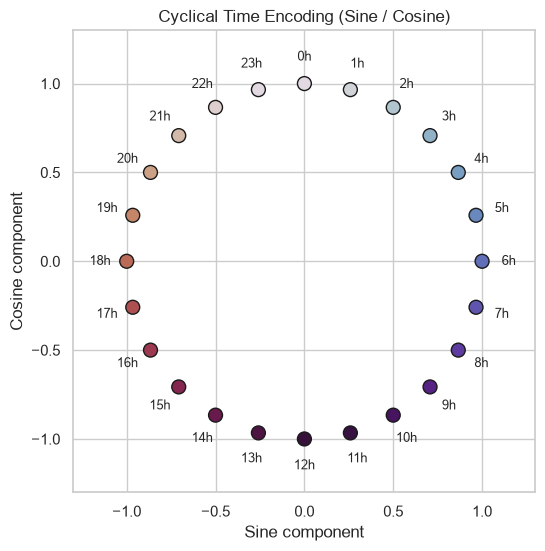

In [4]:
fig, ax = plt.subplots(figsize=(6, 6))
# Create sample data representing 24 hours to plot
hours = np.arange(24)
sin_vals = np.sin(2 * np.pi * hours / 24.0)
cos_vals = np.cos(2 * np.pi * hours / 24.0)

ax.scatter(sin_vals, cos_vals, c=hours, cmap='twilight', s=100, edgecolors='k')
for i, h in enumerate(hours):
    ax.text(sin_vals[i]*1.15, cos_vals[i]*1.15, f"{h}h", ha='center', va='center', fontsize=9)

ax.set_title("Cyclical Time Encoding (Sine / Cosine)")
ax.set_xlabel("Sine component")
ax.set_ylabel("Cosine component")
ax.set_xlim(-1.3, 1.3)
ax.set_ylim(-1.3, 1.3)
ax.set_aspect('equal')
save_figure(fig, "cyclical_time_circle.png")
plt.show()

## 4. Stratified Split (70/15/15)

We split the data, stratifying on `is_fraud` to guarantee class distribution consistency across train, validation, and test splits.

In [5]:
X_train, X_val, X_test, y_train, y_val, y_test = split_data(df_encoded, target_col='is_fraud')

# Verify that proportions are roughly equal
print(f"Train Fraud Rate: {y_train.mean():.4f}")
print(f"Val Fraud Rate:   {y_val.mean():.4f}")
print(f"Test Fraud Rate:  {y_test.mean():.4f}")
assert np.isclose(y_train.mean(), y_val.mean(), atol=1e-3)
assert np.isclose(y_train.mean(), y_test.mean(), atol=1e-3)

Split completed (stratified):
  Train: X=(7000, 13), y=(7000,), fraud rate=1.50%
  Val:   X=(1500, 13), y=(1500,), fraud rate=1.53%
  Test:  X=(1500, 13), y=(1500,), fraud rate=1.53%
Train Fraud Rate: 0.0150
Val Fraud Rate:   0.0153
Test Fraud Rate:  0.0153


## 5. Feature Scaling (StandardScaler)

Continuous numeric columns are standard scaled. We fit on the training data ONLY, and then transform val/test to prevent information/data leakage.

In [6]:
X_train_scaled, X_val_scaled, X_test_scaled = scale_features(X_train, X_val, X_test)

# Verify scaling properties (mean = 0, std = 1 on training split)
scaled_cols = ['amount', 'device_trust_score', 'velocity_last_24h', 'cardholder_age']
print("Training Means after scaling (Expected: ~0):")
print(X_train_scaled[scaled_cols].mean())
print("\nTraining Stds after scaling (Expected: ~1):")
print(X_train_scaled[scaled_cols].std())

assert np.allclose(X_train_scaled[scaled_cols].mean(), 0, atol=1e-7)
assert np.allclose(X_train_scaled[scaled_cols].std(ddof=0), 1, atol=1e-7)

Scaled continuous columns: ['amount', 'device_trust_score', 'velocity_last_24h', 'cardholder_age']
Training Means after scaling (Expected: ~0):
amount               -1.969218e-16
device_trust_score    1.928616e-17
velocity_last_24h    -7.105427e-18
cardholder_age       -1.258676e-16
dtype: float64

Training Stds after scaling (Expected: ~1):
amount                1.000071
device_trust_score    1.000071
velocity_last_24h     1.000071
cardholder_age        1.000071
dtype: float64


## 6. SMOTE Balancing

We apply SMOTE to balance the minority target class on the **training set only**. The validation and test sets remain unbalanced to represent real-world transaction distributions.

In [7]:
X_train_smote, y_train_smote = apply_smote(X_train_scaled, y_train)

print(f"Balanced Train Split Class Counts:\n{y_train_smote.value_counts()}")

SMOTE applied. Original shape: (7000, 13), Balanced shape: (13790, 13)
  Original fraud: 105 (1.50%)
  Balanced fraud: 6895 (50.00%)
Balanced Train Split Class Counts:
is_fraud
0    6895
1    6895
Name: count, dtype: int64


## 7. Data Persistence

We save the scaled splits (both imbalanced and SMOTE-balanced train sets, and validation/test sets) to the `data/processed/` directory. This decouples preprocessing from model training.

In [8]:
processed_dir = os.path.join(project_root, "data", "processed")
os.makedirs(processed_dir, exist_ok=True)

# Save training sets
X_train_scaled.to_csv(os.path.join(processed_dir, "X_train_raw.csv"), index=False)
y_train.to_csv(os.path.join(processed_dir, "y_train_raw.csv"), index=False)
X_train_smote.to_csv(os.path.join(processed_dir, "X_train_smote.csv"), index=False)
y_train_smote.to_csv(os.path.join(processed_dir, "y_train_smote.csv"), index=False)

# Save validation and test sets
X_val_scaled.to_csv(os.path.join(processed_dir, "X_val.csv"), index=False)
y_val.to_csv(os.path.join(processed_dir, "y_val.csv"), index=False)
X_test_scaled.to_csv(os.path.join(processed_dir, "X_test.csv"), index=False)
y_test.to_csv(os.path.join(processed_dir, "y_test.csv"), index=False)

print(f"Processed data splits successfully saved to {processed_dir}")

Processed data splits successfully saved to /home/ikartiksavaliya/Desktop/Portfolio projects/DL/credit-card-fraud-detection-system/data/processed
